In [1]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import numpy as np
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# set up some print options
#np.set_printoptions(precision = 3, suppress = True)
torch.set_printoptions(precision=2,linewidth=160)
#begin loggin
cur_dir = 'synthetic' 
os.makedirs(cur_dir, exist_ok=True)

# Set up common problem parameters
lr = 0.02
clip_r = lr
n = 10        # dimension
n_head = 1  # 1-headed attention
batch_size = 4000  # 1000 minibatch size
var = 0.1  # initializations scale of transformer parameter
max_iters = 40100  # Number of Iterations to run
stride = 400


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)

In [2]:
# B is n x d incidence matrix taking values in {-1,0,1}
# assumed to output fully-connected graph, so d = n(n-1)/2
# unweighted
def gen_fc_unit_incidence(n):
    d = int(n * (n-1)/2)
    B = torch.zeros(n, d).cuda()
    edge_id = 0
    for i in range(n):
        for j in range(n):
            if j <=i:
                continue
            else:
                B[i,edge_id] = 1
                B[j,edge_id] = -1
                edge_id += 1
    return B.to(device)

def get_laplacian(B):
    #i is batch index
    return torch.einsum('ijk,ilk->ijl', B, B)

# circular skip list, each node has 4 incident edges
# unweighted
def gen_csl_unit_incidence(n):
    d = 2*n
    B = torch.zeros(4, n, d).to(device)
    skip_values = [2,4,6,8]
    # loop over skip values
    for sk_i in range(len(skip_values)):
        list_src = []
        list_dst = []
        skip_value = skip_values[sk_i]
        for i in range(n):
            # cycle
            list_src.append(i)
            list_dst.append((i+1)%n)
            # skip connection
            list_src.append(i)
            list_dst.append((i+skip_value)%n)
        for (ind_e, (i,j)) in enumerate(zip(list_src, list_dst)):
            B[sk_i, i, ind_e] = 1
            B[sk_i, j, ind_e] = -1
    return B

#given Z of shape batch_size x n x d
#generate a incidence matrix for i \in [0, batch_size-1]
#generate random edge weights
#randomly permutes the edge ids
def generate_B_inplace(Z, nv):
    batch_size = Z.shape[0]
    Z[:,:,0:d] = gen_csl_unit_incidence(n)[:,:,:].repeat(int(batch_size/4),1,1)
    #Z[:,:,0:d] = gen_fc_unit_incidence(n)[None,:,:].repeat(int(batch_size),1,1)
    rand_edge_weights = (torch.exp((torch.rand([batch_size, d]))*2-1))[:,None,:].to(device)
    Z[:,:,0:d] = Z[:,:,0:d] * rand_edge_weights

    for i in range(10):
        stride = int(Z.shape[0]/10)
        Z[(i * stride) : ((i+1) * stride),:,0:d] = Z[(i * stride) : ((i+1) * stride),:,torch.randperm(d)]
        Z[(i * stride) : ((i+1) * stride),0:n,:] = Z[(i * stride) : ((i+1) * stride),torch.randperm(n),:]
    return Z

#loss corresponding to error in eigenvectors computed
#inds denotes the eigenvector indices we care about, 0 is smallest, n-1 is largest eigenvalue
#considers invariance up to sign flip
#automatically normalizes the output of the model to norm=1
def L_ev_loss(model, Z, inds = None):
    n = Z.shape[1]
    d = Z.shape[2] - n - n

    lap = get_laplacian(Z[:,:,0:d])
    _, target  = torch.linalg.eigh(lap)
    target = target.real
    


    output = model(Z)
    predicted_ev = output[:,:,d+n:d+n+n]
    if inds == None:
        predicted_ev = predicted_ev[:,:,:]
        target = target[:,:,:]
    else:
        assert(max(inds) < target.shape[2])
        predicted_ev = predicted_ev[:,:,inds]
        target = target[:,:,inds]
    
    predicted_ev = predicted_ev/predicted_ev.norm(p=2,dim=1)[:,None,:]
    target = target/target.norm(p=2,dim=1)[:,None,:]
    loss_pos = ((predicted_ev - target).norm(p=2, dim=[1])**2)
    loss_neg = ((-predicted_ev - target).norm(p=2, dim=[1])**2)
    loss = torch.minimum(loss_pos, loss_neg).sum([1]).mean()
    return loss

# if ||grad|| > c, then grad = grad/||grad||*c
def clip_and_step(allparam, optimizer, clip_r = None):
    norm_p=None
    grad_all = allparam.grad
    norm_p = grad_all.norm().item()
    if norm_p > clip_r:
        grad_all.mul_(clip_r/norm_p)
        fraction = clip_r/norm_p
    else:
        fraction = 1.0
    optimizer.step()
    return fraction

In [3]:
#attention but without softmax
def linear_attention(P,Q,K,Z):
    n = Z.shape[1]
    QK = torch.einsum('Hji,Hjk->Hik', (Q,K))
    #Attn if QK is d+n+n by d+n+n
    Attn = torch.einsum('BNi, Hij, BMj -> HBNM', (Z,QK,Z))
    # if QK were a vector of diagonals of dimension d+n+n, instead do
    # Attn = torch.einsum('BNi, Hi, BMi -> HBNM', (Z,QK,Z))

    # usually would do Attn = softmax(Attn)
    PZ = torch.einsum('Hij, BNj -> HBNi', (P,Z))
    Output = torch.einsum('HBNi, HBNM -> BMi', (PZ,Attn))
    return Output /n
    
class Transformer_LG(nn.Module):
    def __init__(self, n_layer, n_head, n, d, var):
        super(Transformer_LG, self).__init__()
        # dnchange
        self.register_parameter('allparam', torch.nn.Parameter(torch.zeros(n_layer, n_head, 5, d+n+n, d+n+n)))
        with torch.no_grad():
            self.allparam.normal_(0,var)
            self.allparam[:,:,0,:,:].zero_()
            self.allparam[:,:,1,:,:].copy_(torch.eye(d+n+n).to(device).expand_as(self.allparam[:,:,1,:,:]))
            self.allparam[:,:,2,:,:].copy_(torch.eye(d+n+n).to(device).expand_as(self.allparam[:,:,2,:,:]))
            #self.allparam[:,:,3,:,:].copy_(torch.eye(d+n+n).to(device).expand_as(self.allparam[:,:,3,:,:]))
            self.allparam[:,:,3,:,:].zero_()
        self.n_layer = n_layer
        self.n_head = n_head
        self.n = n
        self.d = d

    #Zi is transformer output at ith layer
    #Z(i+1) = Zi + linear_attn(Zi) + linear(Zi)
    def forward(self, Z, early_stop = 1000):
        d = self.d
        n = self.n
        init_mask = torch.cat( (torch.zeros(n,d).to(device), self.allparam[0,0,4,0:n,0:n+n]), dim = 1)
        Z = Z + init_mask[None,:,:]
        #first d columns of Z are B
        #d:d+n+n  columns of Z are phi
        for i in range(self.n_layer):
            Zi = Z
            residues = 0
            # the forwarad map of each layer is given by F(Z) = Z + attention(Z)
            Pij = self.allparam[i,:,0,:,:]
            Qij = self.allparam[i,:,1,:,:]
            Kij = self.allparam[i,:,2,:,:]
            residues = residues + linear_attention(Pij,Qij,Kij,Zi)
            Z = Zi + residues + torch.nn.functional.linear(input = Z, weight = self.allparam[i,0,3,:,:])
            
            #normalization on Zi = [Bi; phi_i]. normalize Bi (first d columns) and phi_i (d:d+n+n columns) separately.
            norms = torch.cat((Z[:,:,0:d].norm(p=2,dim=[1,2])[:,None,None].expand(Z.shape[0],n,d),
                  (Z[:,:,d:d+n]+1e-6).norm(p=2,dim=[1])[:,None,:].expand(Z.shape[0],n,n),
                  (Z[:,:,d+n:d+n+n]+1e-6).norm(p=2,dim=[1])[:,None,:].expand(Z.shape[0],n,n)), dim=2)
            Z = Z/(norms[:,:,:])
            if early_stop == i:
                break
        return Z

In [5]:
seeds=[0,1,2]
n_layers = [9,7,5,3,1]  # number of layers of transformer
n_heads = [1]
keys = []
for n_layer in n_layers:
    for n_head in n_heads:
        for s in seeds:
            keys.append((n_layer,n_head,s,))
            #keys.append((s,n_layer,'SP',))
clip_r=0.02


print(f"lr: {lr}")
#d = int(n*(n-1)/2)
d = 2*n
filename = cur_dir + '/ev_csl_exp.pth'
try:
    hist_dict = torch.load(filename)
    torch.save(hist_dict, filename)
except:
    hist_dict={}
    torch.save({}, filename)

iter_dict = {9:40100, 7:14100, 5:8100, 3:6100, 1:4100}

for key in keys:
    n_layer = key[0]
    n_head = key[1]
    sd = key[2]

    max_iters = iter_dict[n_layer]
    stride = int(max_iters/100)

    lr = 0.01/n_layer
    print(key)
    prob_seed = sd
    opt_seed = sd
    hist_dict[key] = []
    
    #set seed and initialize model
    torch.manual_seed(opt_seed)
    model = Transformer_LG(n_layer, n_head, n, d, 0.1).to(device)
    #initialize algorithm.
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.001)

    # set seed
    # sample random rotation matrix
    # initialize initial training batch
    np.random.seed(prob_seed)
    torch.manual_seed(prob_seed)
    # dnchange 
    Z = torch.zeros([batch_size,n,d+n+n]).to(device)
    generate_B_inplace(Z, n)
    #generate_demand_inplace(Z, n)
    
    residual_lr = lr
    
    for t in range(max_iters):
        optimizer.param_groups[0]['lr'] = residual_lr
        if t%(10*stride)==0 and t>1:
            residual_lr = residual_lr * 0.5
        # save model parameters
        if t%stride ==0:
            hist_dict[key].append(model.allparam.clone().detach().cpu())

        loss = L_ev_loss(model, Z, [1,2,3,4,5,6,7,8,9])
        # compute gradient, take step
        loss.backward()
        fraction = clip_and_step(model.allparam, optimizer, clip_r=clip_r)
        norms = model.allparam.grad.norm().item()
        #model.zero_QK_L()
        optimizer.zero_grad()

        if t%10==0:
            generate_B_inplace(Z, n)
            #generate_demand_inplace(Z, n)
        if t%200 ==0 or t<5:
            print('iter {} | Loss: {:.3}, naive: {:.3}, gradnorm: {:.2}, fraction:{}'\
                  .format(t,loss.item(), 0.0, norms, fraction))
    torch.save(hist_dict, filename)

lr: 0.02
(9, 1, 0)
iter 0 | Loss: 13.3, naive: 0.0, gradnorm: 0.02, fraction:0.002532083868082076
iter 1 | Loss: 13.2, naive: 0.0, gradnorm: 0.02, fraction:0.0026300722258041174
iter 2 | Loss: 13.1, naive: 0.0, gradnorm: 0.02, fraction:0.002471555308797687
iter 3 | Loss: 12.9, naive: 0.0, gradnorm: 0.02, fraction:0.0025454282621465143
iter 4 | Loss: 12.8, naive: 0.0, gradnorm: 0.02, fraction:0.0028470683905319097
iter 200 | Loss: 7.58, naive: 0.0, gradnorm: 0.02, fraction:0.005749406287289099
iter 400 | Loss: 6.41, naive: 0.0, gradnorm: 0.02, fraction:0.003634882812990861
iter 600 | Loss: 5.61, naive: 0.0, gradnorm: 0.02, fraction:0.004470108820183562
iter 800 | Loss: 5.0, naive: 0.0, gradnorm: 0.02, fraction:0.002733095135573588
iter 1000 | Loss: 4.59, naive: 0.0, gradnorm: 0.02, fraction:0.002156004010267469
iter 1200 | Loss: 4.18, naive: 0.0, gradnorm: 0.02, fraction:0.0023403214634329793
iter 1400 | Loss: 3.9, naive: 0.0, gradnorm: 0.02, fraction:0.002892277970658953
iter 1600 | Lo

In [6]:
print(hist_dict.keys())

dict_keys([(9, 1, 0), (9, 1, 1), (9, 1, 2), (7, 1, 0), (7, 1, 1), (7, 1, 2), (5, 1, 0), (5, 1, 1), (5, 1, 2), (3, 1, 0), (3, 1, 1), (3, 1, 2), (1, 1, 0), (1, 1, 1), (1, 1, 2)])


In [54]:
torch.save({},filename)

In [17]:
model = Transformer_LG(3, 1, n, d, 0.01)
with torch.no_grad():
    model.allparam.data = hist_dict[(3,1,0)][-1]

model.to(device)

Z = torch.zeros([batch_size,n,d+n+n]).to(device)
generate_B_inplace(Z, n)
for i in range(10):
    print(i, L_ev_loss(model, Z, [i]))

0 tensor(0.00, device='cuda:0', grad_fn=<MeanBackward0>)
1 tensor(0.85, device='cuda:0', grad_fn=<MeanBackward0>)
2 tensor(1.07, device='cuda:0', grad_fn=<MeanBackward0>)
3 tensor(1.17, device='cuda:0', grad_fn=<MeanBackward0>)
4 tensor(1.19, device='cuda:0', grad_fn=<MeanBackward0>)
5 tensor(1.12, device='cuda:0', grad_fn=<MeanBackward0>)
6 tensor(0.98, device='cuda:0', grad_fn=<MeanBackward0>)
7 tensor(0.73, device='cuda:0', grad_fn=<MeanBackward0>)
8 tensor(0.31, device='cuda:0', grad_fn=<MeanBackward0>)
9 tensor(0.07, device='cuda:0', grad_fn=<MeanBackward0>)


In [14]:
hist_dict = torch.load(filename, map_location='cpu')
print(hist_dict.keys())

dict_keys([(11, 1, 0), (11, 1, 1), (11, 1, 2), (9, 1, 0), (9, 1, 1), (9, 1, 2), (7, 1, 0), (7, 1, 1), (7, 1, 2), (5, 1, 0), (5, 1, 1), (5, 1, 2), (3, 1, 0), (3, 1, 1), (3, 1, 2), (1, 1, 0), (1, 1, 1), (1, 1, 2)])


In [20]:
torch.manual_seed(0)
Z = torch.zeros([batch_size,n,d+n+n]).to(device)
generate_B_inplace(Z, n)
for i in range(10):
    print(i, L_ev_loss(model, Z, [i]))

0 tensor(0.00, device='cuda:0', grad_fn=<MeanBackward0>)
1 tensor(0.95, device='cuda:0', grad_fn=<MeanBackward0>)
2 tensor(1.12, device='cuda:0', grad_fn=<MeanBackward0>)
3 tensor(1.23, device='cuda:0', grad_fn=<MeanBackward0>)
4 tensor(1.21, device='cuda:0', grad_fn=<MeanBackward0>)
5 tensor(1.13, device='cuda:0', grad_fn=<MeanBackward0>)
6 tensor(1.00, device='cuda:0', grad_fn=<MeanBackward0>)
7 tensor(0.82, device='cuda:0', grad_fn=<MeanBackward0>)
8 tensor(0.38, device='cuda:0', grad_fn=<MeanBackward0>)
9 tensor(0.10, device='cuda:0', grad_fn=<MeanBackward0>)


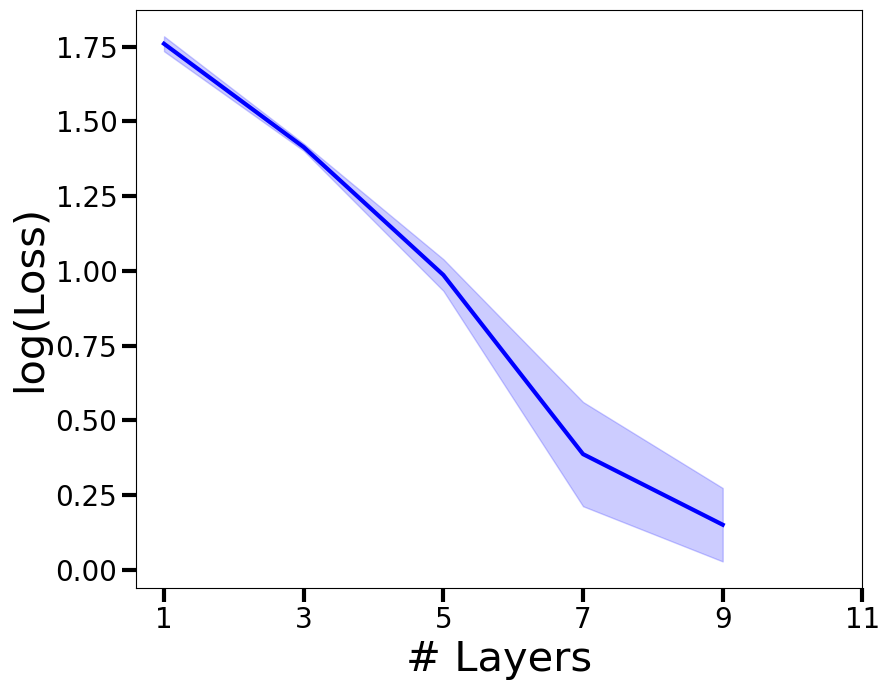

In [28]:
n_head = 1
losses_ev = torch.zeros(len(n_layers), len(seeds))

for i in range(len(n_layers)):
    for seed in seeds:
        n_layer = n_layers[i]
        
        model_hist = hist_dict[(n_layer,n_head,seed)]
        model = Transformer_LG(n_layer, n_head, n, d, 0.01)
        with torch.no_grad():
            model.allparam.data = model_hist[-1]
        model.to(device)
        losses_ev[i, seed] = L_ev_loss(model,Z).log()
        
loss_mean_ev = torch.mean(losses_ev, axis=1).cpu().detach().numpy()
loss_std_ev = torch.std(losses_ev, axis=1).cpu().detach().numpy()
    
fig, ax = plt.subplots(1, 1,figsize = (9, 7))

plt.plot(n_layers, loss_mean_ev, color='blue', lw = 3)#, label='1 head')
ax.fill_between(n_layers, loss_mean_ev-loss_std_ev, loss_mean_ev+loss_std_ev, color = 'blue', alpha = 0.2)


ax.set_xlabel('# Layers',fontsize=30)
ax.set_ylabel('log(Loss)',fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20, width = 3, length = 10)
ax.tick_params(axis='both', which='minor', labelsize=20, width = 3, length = 5)
plt.xticks([1,3,5,7,9,11])
plt.tight_layout()

In [ ]:
n_layer = 9
n_head = 1
losses_ev = torch.zeros(n_layer, n, len(seeds))

for seed in seeds:
    model_hist = hist_dict[(n_layer,n_head,seed)]
    model = Transformer_LG(n_layer, n_head, n, d, 0.01).to(device)
    with torch.no_grad():
        model.allparam.data = model_hist[-1]
    model.to(device)
    for i in range(1,n_layer):
        for j in range(n):
            losses_ev[i, j, seed] = L_ev_loss_plot(model(Z, early_stop = i), Z, [j]).log()
        
loss_mean_ev = torch.mean(losses_ev, axis=2).cpu().detach().numpy()
loss_std_ev = torch.std(losses_ev, axis=2).cpu().detach().numpy()
    
fig, ax = plt.subplots(1, 1,figsize = (9, 7))

c = [
    "#FF0000",  # Red
    "#FF7F00",  # Orange
    "#FFFF00",  # Yellow
    "#00FF00",  # Green
    "#0000FF",  # Blue
    "#4B0082",  # Indigo
    "#8B00FF",  # Violet
    "#FFC0CB",  # Pink
    "#A52A2A",  # Brown
    "#808080"   # Gray
]

for j in range(1,n):
    plt.plot(range(n_layer), loss_mean_ev[:,j], color=c[j], lw = 1, label='{}'.format(j+1))
    ax.fill_between(range(n_layer), loss_mean_ev[:,j]-loss_std_ev[:,j], loss_mean_ev[:,j]+loss_std_ev[:,j], color = c[j], alpha = 0.2)


ax.set_xlabel('# Layer',fontsize=30)
ax.set_ylabel('log(Loss)',fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20, width = 3, length = 10)
ax.tick_params(axis='both', which='minor', labelsize=20, width = 3, length = 5)
plt.xticks(range(n_layer))
ax.legend(fontsize=12)

plt.tight_layout()
#plt.savefig(fig_dir + '/ev_loss_per_ev_intermediate.pdf', dpi=600)